In [1]:
import warnings

warnings.simplefilter("ignore")
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from lightkurve import LightCurve
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

search_result = search_lightcurve("AU Mic") 
lc2min = search_result[7].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

In [2]:
vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.195,2041.387],
    [2037.663,2037.787],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.26492, 2039.26775],
    [2039.34872, 2039.35791],
    [2039.82051, 2039.84413],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2046.6233,2046.6573],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.50326, 2047.51074],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2051.83676,2051.84445],
    [2052.6758,2052.7025],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.82836, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.83466, 2058.9741],
    [2059.0975,2059.1182],
    [2059.10883, 2059.11091],
    [2058.803,2058.912],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109],
    [2060.5012,2060.5220]
]

with open("vetores.txt", "w") as file:
    for vetor in vetores:
        file.write(f"{vetor[0]} {vetor[1]}\n")

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)



valores = [
    [2036.7051, 2036.71029],
    [2037.44301, 2037.45116],
    [2037.67311, 2037.73284],
    [2039.1808, 2039.19745],
    [2039.26492, 2039.26847],
    [2039.34872, 2039.36633],
    [2039.80907, 2039.8322],
    [2040.0282, 2040.0972],
    [2041.1855, 2041.3798],
    [2042.48388, 2042.5350],
    [2047.21322, 2047.2433],
    [2047.34522, 2047.36154],
    [2047.5036, 2047.51074],
    [2047.62795, 2047.6467],
    [2047.83154, 2047.83627],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.74298],
    [2049.6730, 2049.8201],
    [2050.78041, 2050.7841],
    [2050.8560, 2050.8799],
    [2050.31549, 2050.31673],
    [2051.1625,2051.2091],
    [2051.44076, 2051.5667],
    [2053.08171, 2053.08283],
    [2053.42735, 2053.5686],
    [2054.2776,2054.3618],
    [2055.90134, 2055.9496],
    [2056.26941, 2056.27359],
    [2056.82718, 2056.8597],
    [2056.90861, 2057.1060],
    [2057.7987, 2057.8672],
    [2058.1318, 2058.2471],
    [2058.24047, 2058.24378],
    [2058.83466, 2058.8589],
    [2059.54703, 2059.5660],
]


valores_true = [False]*len(x2min)
for j in range(len(x2min)):
    for i in range(len(valores)):
        if (x2min[j]>=valores[i][0]) and (x2min[j]<=valores[i][1]):
            valores_true[j] = True

mascara_1 = np.array(valores_true)

with open("setor27_20s_novo.txt", "w") as file:
    for vetor in valores:
        file.write(f"{vetor[0]} {vetor[1]}\n")

valores_true = [False]*len(x2min)

In [3]:
flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
tempo_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
fluxo_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)

###############################################################################################################################################################
xdefinitivo2 = []
ydefinitivo2 = []
for j in range(len(y2min)):
    if 2039.7849 < x2min[j] < 2040.3834:
        xdefinitivo2.append(x2min[j])
        ydefinitivo2.append(y2min[j])

xdefinitivo2 = np.array(xdefinitivo2)
ydefinitivo2 = np.array(ydefinitivo2)

vetores1 = [
    [2039.8183, 2039.8489],
    [2040.0265,2040.0973]    
]
vetor_true1 = [False]*len(xdefinitivo2)

for j in range(len(xdefinitivo2)):
    for i in range(len(vetores1)):
        if (xdefinitivo2[j]>=vetores1[i][0]) and (xdefinitivo2[j]<=vetores1[i][1]):
            vetor_true1[j] = True

mascara1 = np.array(vetor_true1)

lc =  LightCurve(time=xdefinitivo2, flux=ydefinitivo2)
flcd2 = lc.flatten(window_length=100, polyorder=2, return_trend=False, break_tolerance=15, niters=2, sigma=2.5, mask=mascara1)

# Access the detrended LightCurve
#detrended_lc = flcd2[1]
#original_lc = flcd2[0]
detrended_lc = flcd2

tempo_detrend1 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend1 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)
##########################################################################################################################################################
xdefinitivo3 = []
ydefinitivo3 = []
for j in range(len(y2min)):
    if 2044.7117 < x2min[j] < 2045.1598:
        xdefinitivo3.append(x2min[j])
        ydefinitivo3.append(y2min[j])

xdefinitivo3 = np.array(xdefinitivo3)
ydefinitivo3 = np.array(ydefinitivo3)
'''
vetores2 = [
    [1338.2152,1338.3017]
]
vetor_true2 = [False]*len(xdefinitivo3)

for j in range(len(xdefinitivo3)):
    for i in range(len(vetores2)):
        if (xdefinitivo3[j]>=vetores2[i][0]) and (xdefinitivo3[j]<=vetores2[i][1]):
            vetor_true2[j] = True

mascara3 = np.array(vetor_true2)
'''
lc2 =  LightCurve(time=xdefinitivo3, flux=ydefinitivo3)
flcd3 = lc2.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=10, niters=3, sigma=2.5, mask=None)

detrended_lc = flcd3

tempo_detrend3 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend3 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)


#########################################################################################################################################################################
##############################################################################################################################################################

xdefinitivo5 = []
ydefinitivo5 = []
for j in range(len(y2min)):
    if 2036.9691 < x2min[j] < 2037.0210:
        xdefinitivo5.append(x2min[j])
        ydefinitivo5.append(y2min[j])


xdefinitivo5 = np.array(xdefinitivo5)
ydefinitivo5 = np.array(ydefinitivo5)

vetores3 = [
    [2036.9750,2036.9821],
    [2037.0037,2037.0185],
    [2037.0297,2037.0343]
]
vetor_true3 = [False]*len(xdefinitivo5)

for j in range(len(xdefinitivo5)):
    for i in range(len(vetores3)):
        if (xdefinitivo5[j]>=vetores3[i][0]) and (xdefinitivo5[j]<=vetores3[i][1]):
            vetor_true3[j] = True

mascara5 = np.array(vetor_true3)


lc5 =  LightCurve(time=xdefinitivo5, flux=ydefinitivo5)
flcd5 = lc5.flatten(window_length=50, polyorder=2, return_trend=False, break_tolerance=20, niters=3, sigma=2.5, mask=mascara5)

detrended_lc = flcd5

tempo_detrend5 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend5 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)


#########################################################################################################################################################################
########### O FOR PARA O CORTE DOS VALORES QUE ESTÃO COM NORMALIZAÇÃO RUIM E ADICIONAR NA NORMALIZAÇÃO MELHOR######################################################
count = 0
count1 = 0
count2 = 0
count3 = 0

for j in range(len(tempo_detrend)):
    if tempo_detrend[j]>=2039.7849 and  tempo_detrend[j]<=2040.3834:
       fluxo_detrend[j]= fluxo_detrend1[count]
       tempo_detrend[j]= tempo_detrend1[count]
       count = count + 1
    if tempo_detrend[j]>= 2044.7117 and  tempo_detrend[j]<= 2045.1598:
       fluxo_detrend[j]= fluxo_detrend3[count1]
       tempo_detrend[j]= tempo_detrend3[count1]
       count1 = count1 + 1
    if tempo_detrend[j]>= 2036.9691 and  tempo_detrend[j]<=2037.0210:
       fluxo_detrend[j]= fluxo_detrend5[count3]
       tempo_detrend[j]= tempo_detrend5[count3]
       count3 = count3 + 1
    

In [4]:
############ PARA CALCULAR A MÉDIA E O DESVIO DO RUIDO ########################################################################################################################  
x_detrend = []
y_detrend = []
for j in range(len(mascara_1)):
    if mascara_1[j] == False:
        y_detrend.append(fluxo_detrend[j])
        x_detrend.append(tempo_detrend[j])

x_detrend = np.array(x_detrend)
y_detrend = np.array(y_detrend)


y_mean = np.mean(y_detrend)
#Media para todos os pontos do eixo x, para apresentar no grafico 
#y_mean2 = [y_mean for i in range(len(y))]
y_mean2 = [y_mean]*len(y_detrend)
#Calculo do desvio padrao dos dados
desvio = (np.std(y_detrend))
print(y_mean)
#Media mais desvio padrao
med_desv = y_mean2+desvio

#Corte nos valores de média+ 2*sigma

med_desv2 = y_mean + (2*desvio)
med_desv3 = y_mean - (2*desvio)
xdefinitivo = []
ydefinitivo = []
for j in range(len(y_detrend)):
    if y_detrend[j] < med_desv2 and y_detrend[j]>med_desv3:
        ydefinitivo.append(y_detrend[j])
        xdefinitivo.append(x_detrend[j])

xdefinitivo = np.array(xdefinitivo)
ydefinitivo = np.array(ydefinitivo)

#Calculo novo da média e do desvio padrão do ruido 
y_m = np.mean(ydefinitivo)
y_m2 = [y_m]*len(ydefinitivo)
desvio2 = (np.std(ydefinitivo))
#med = desvio2
med = y_m2 + desvio2
med2 = y_m + 3*desvio2

1.000011463550345


<IPython.core.display.Javascript object>


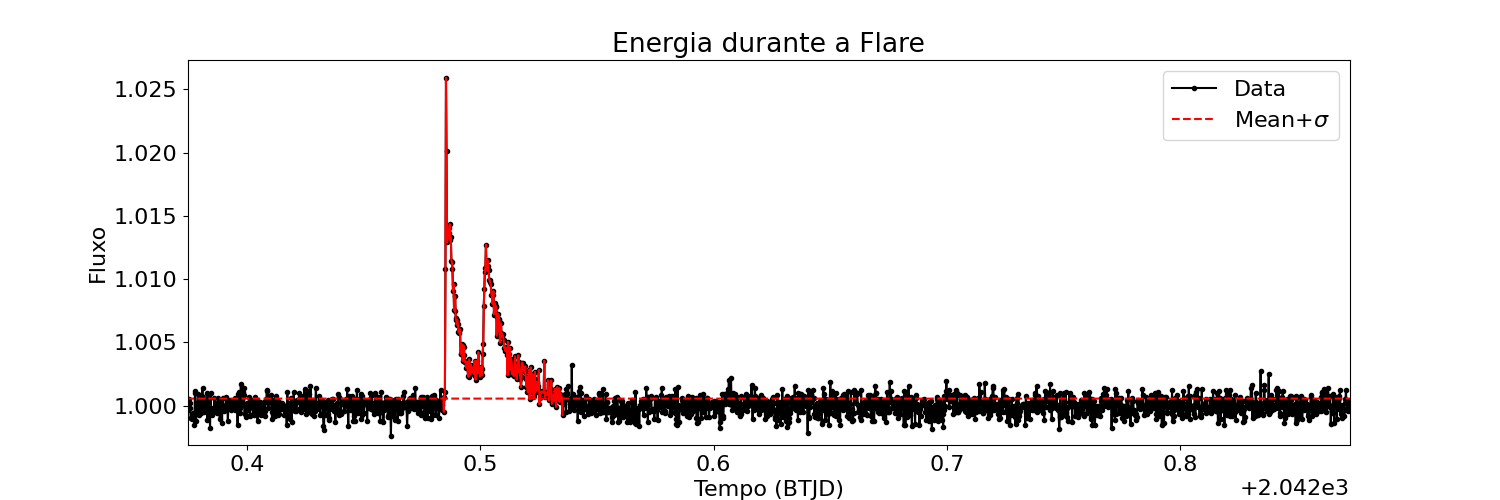

In [8]:
%matplotlib notebook
plt.rcParams['font.size'] = 16
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plote os dados
data_line = ax.plot(tempo_detrend, fluxo_detrend, marker='.', color='black', label='Data')

# Plote os picos
#ax.plot(tempo_detrend[peaks], fluxo_detrend[peaks], 'bx', label='Picos')

# Plote a linha tracejada da média
ax.plot(xdefinitivo, med, label='Mean+$\sigma$', linestyle='--', color='red')

#ax.plot(xdefinitivo, y_m2, label='Média', linestyle='--', color='blue')
# Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux', rasterized=True)
plt.show()

In [10]:
# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 2042.48388
stop_input =  2042.5353 


def ener_flare(start, stop, tempo_detrend, fluxo_detrend):
    flux_flare = []
    tempo_flare = []
    for i in range(len(tempo_detrend)):
        if tempo_detrend[i] >= start and tempo_detrend[i] <= stop:
            flux_flare.append(fluxo_detrend[i])
            tempo_flare.append(tempo_detrend[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare
#print(flux_flare)
#print(tempo_flare)
# Chamada da função ener_flare com os dados de exemplo
#fig,ax = plt.subplots(1,1,figsize=(10,5))
flux_flare, tempo_flare = ener_flare(start_input, stop_input, tempo_detrend, fluxo_detrend)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
#fig,ax = plt.subplots(1,1,figsize=(10,5))
plt.plot(tempo_flare, flux_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()